# 1. Set up

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import os

# set seed
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
CURR_DIR = os.getcwd() 

# ================================================================
# Choose your dataset + split mode
# ================================================================

DATASET = "processed_emodb_comb_norm_loso"

# SPLIT_MODE = "original"   # "original" or "loso"
SPLIT_MODE = "loso"

# ================================================================

DATASET_PATH = os.path.join(CURR_DIR, DATASET)

MODEL_DIR = os.path.join(CURR_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DCNN_NAME = f"dcnn_{DATASET}.pth"
SVM_NAME = f"svm_{DATASET}.joblib"

DCNN_PATH = os.path.join(MODEL_DIR, DCNN_NAME)
SVM_PATH = os.path.join(MODEL_DIR, SVM_NAME)

RESULTS_DIR = os.path.join(CURR_DIR, "results", DATASET)
os.makedirs(RESULTS_DIR, exist_ok=True)

if SPLIT_MODE == "loso":
    FOLD_NAMES = sorted([
        name for name in os.listdir(DATASET_PATH)
        if name.startswith("fold") and os.path.isdir(os.path.join(DATASET_PATH, name))
    ])
    if len(FOLD_NAMES) == 0:
        raise ValueError(f"No fold directories found under {DATASET_PATH}. Expected fold1..fold10")
else:
    FOLD_NAMES = []

print(f"Using dataset at           : {DATASET_PATH}")
print(f"Split mode                : {SPLIT_MODE}")
if SPLIT_MODE == "loso":
    print(f"Detected folds             : {FOLD_NAMES}")
print(f"DCNN model path (original) : {DCNN_PATH}")
print(f"SVM model will be saved to : {SVM_PATH}")
print(f"Results will be saved to   : {RESULTS_DIR}")

Using dataset at           : /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/processed_emodb_comb_norm_loso
Split mode                : loso
Detected folds             : ['fold1', 'fold10', 'fold2', 'fold3', 'fold4', 'fold5', 'fold6', 'fold7', 'fold8', 'fold9']
DCNN model path (original) : /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/dcnn_processed_emodb_comb_norm_loso.pth
SVM model will be saved to : /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/svm_processed_emodb_comb_norm_loso.joblib
Results will be saved to   : /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_comb_norm_loso


# 2. Train DCNN

In this section, we fine-tune AlexNet on 3-channel log-Mel segment images (log-Mel, delta, delta-delta).

This notebook supports two modes:
- original: train and evaluate using one fixed train/validation/test split
- loso: run 10 folds (one test speaker per fold), then collate all test-fold predictions into one final result

Recommended run order for Section 2:
1. Set DATASET and SPLIT_MODE in Cell 3
2. Run Cells 6 to 12 in order
3. Check saved artifacts in the dataset-specific results folder

In [3]:
# Transform for image preprocessing
# ToTensor: Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0].
# Resize: Resizes the input image to the given size. Here we resize to (227, 227) which is the input size for AlexNet.
# Normalize: Normalizes a tensor image with mean and standard deviation. The mean and std are calculated from the ImageNet dataset, which is commonly used for pre-trained models.
transform = transforms.Compose([
            transforms.ToTensor(),                          
            transforms.Resize((227, 227), antialias=True),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])
        ])

In [4]:
class MelSegmentDataset(Dataset):
    """Dataset for loading mel-spectrogram segments and labels from .npy files."""
    def __init__(self, x_path, y_path):
        self.X = np.load(x_path)
        self.y = np.load(y_path)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # 1) Read one (3, 64, 64) feature tensor
        img = self.X[idx].copy()

        # 2) Min-max scale each channel independently to [0, 1]
        for c in range(3):
            min_val = img[c].min()
            max_val = img[c].max()
            if max_val > min_val:
                img[c] = (img[c] - min_val) / (max_val - min_val)
            else:
                img[c] = 0.0

        # 3) Convert (C, H, W) -> (H, W, C) for torchvision transforms
        img = img.transpose(1, 2, 0)

        # 4) Apply resize + ImageNet normalization
        return self.transform(img).float(), torch.tensor(self.y[idx], dtype=torch.long)

def build_dataloaders(dataset_dir, batch_size=32):
    train_dataset = MelSegmentDataset(
        os.path.join(dataset_dir, "X_train.npy"),
        os.path.join(dataset_dir, "y_train.npy")
    )
    validation_dataset = MelSegmentDataset(
        os.path.join(dataset_dir, "X_validation.npy"),
        os.path.join(dataset_dir, "y_validation.npy")
    )
    test_dataset = MelSegmentDataset(
        os.path.join(dataset_dir, "X_test.npy"),
        os.path.join(dataset_dir, "y_test.npy")
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, validation_loader, test_loader

# Keep original behavior for non-LOSO mode
if SPLIT_MODE == "original":
    train_loader, validation_loader, test_loader = build_dataloaders(DATASET_PATH, batch_size=32)
else:
    print("LOSO mode: dataloaders are built fold-by-fold in the training cell.")

LOSO mode: dataloaders are built fold-by-fold in the training cell.


In [5]:
def create_dcnn_model(device):
    # Initialize pre-trained AlexNet
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

    # Replace the classifier head for 7 emotion classes
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, 7)
    return model.to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if SPLIT_MODE == "original":
    model = create_dcnn_model(device)
else:
    print("LOSO mode: model will be initialized inside each fold loop.")

LOSO mode: model will be initialized inside each fold loop.


In [6]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    return running_loss / len(dataloader)

def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return running_loss / len(dataloader), accuracy


# Capture all training prints so they can be saved into the report file
dcnn_training_logs = []
def log_dcnn(message):
    print(message)
    dcnn_training_logs.append(str(message))

In [7]:
from sklearn.metrics import accuracy_score

# Training setup (SGD, lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()
PATIENCE = 5

def majority_vote(labels):
    # If multiple labels have equal max count, pick one arbitrarily (dictionary order).
    counts = {}
    for lb in labels:
        counts[int(lb)] = counts.get(int(lb), 0) + 1
    return max(counts, key=counts.get)

# Reuse training logs list from Cell 9 if available; otherwise create it.
if 'dcnn_training_logs' not in globals():
    dcnn_training_logs = []

def log_dcnn(message):
    print(message)
    dcnn_training_logs.append(str(message))

def train_dcnn_one_run(model, train_loader, validation_loader, save_path, max_epochs=50):
    """Train one DCNN model with early stopping on validation loss."""
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    best_val_loss = float('inf')
    counter = 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = evaluate(model, validation_loader, criterion)

        log_dcnn(
            f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), save_path)
            log_dcnn(f"Validation loss improved, model saved to: {save_path}")
        else:
            counter += 1
            log_dcnn(f"Validation loss did not improve. Counter: {counter}/{PATIENCE}")
            if counter >= PATIENCE:
                log_dcnn("Validation loss increased, stopping early.")
                break

def collect_segment_predictions(model, dataloader):
    """Return segment-level predictions and labels for one test loader."""
    model.eval()
    seg_preds = []
    seg_true = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            seg_preds.extend(preds.tolist())
            seg_true.extend(labels.numpy().tolist())
    return np.array(seg_preds), np.array(seg_true)

if SPLIT_MODE == "original":
    # Single-run training/evaluation
    train_dcnn_one_run(model, train_loader, validation_loader, DCNN_PATH, max_epochs=50)

else:
    # LOSO CV: train one model per fold, evaluate on each fold's test speaker, then collate
    all_y_true_utt = []
    all_y_pred_utt = []
    cv_fold_summaries = []

    for fold_name in FOLD_NAMES:
        log_dcnn("=" * 70)
        log_dcnn(f"Running fold: {fold_name}")
        fold_path = os.path.join(DATASET_PATH, fold_name)
        fold_train_loader, fold_validation_loader, fold_test_loader = build_dataloaders(fold_path, batch_size=32)

        fold_model = create_dcnn_model(device)
        fold_model_path = os.path.join(MODEL_DIR, f"dcnn_{DATASET}_{fold_name}.pth")
        train_dcnn_one_run(
            fold_model,
            fold_train_loader,
            fold_validation_loader,
            fold_model_path,
            max_epochs=50,
        )

        fold_model.load_state_dict(torch.load(fold_model_path, map_location=device))
        seg_preds, seg_true = collect_segment_predictions(fold_model, fold_test_loader)
        u_ids_test = np.load(os.path.join(fold_path, "utterance_ids_test.npy"))

        if not (len(u_ids_test) == len(seg_preds) == len(seg_true)):
            raise ValueError(
                f"Length mismatch in {fold_name}: utterance_ids={len(u_ids_test)}, "
                f"preds={len(seg_preds)}, labels={len(seg_true)}"
            )

        # Aggregate segment predictions into utterance predictions
        utt_pred_buckets = {}
        utt_true_label = {}
        for uid, pred, true_label in zip(u_ids_test, seg_preds, seg_true):
            if uid not in utt_pred_buckets:
                utt_pred_buckets[uid] = []
                utt_true_label[uid] = true_label
            utt_pred_buckets[uid].append(pred)

        y_true_utt_fold = []
        y_pred_utt_fold = []
        for uid, pred_list in utt_pred_buckets.items():
            y_true_utt_fold.append(utt_true_label[uid])
            y_pred_utt_fold.append(majority_vote(pred_list))

        y_true_utt_fold = np.array(y_true_utt_fold)
        y_pred_utt_fold = np.array(y_pred_utt_fold)
        fold_utt_acc = accuracy_score(y_true_utt_fold, y_pred_utt_fold)
        cv_fold_summaries.append((fold_name, fold_utt_acc, len(y_true_utt_fold)))
        log_dcnn(
            f"Fold {fold_name} utterance-level accuracy: {fold_utt_acc * 100:.2f}% "
            f"({len(y_true_utt_fold)} utterances)"
        )

        all_y_true_utt.extend(y_true_utt_fold.tolist())
        all_y_pred_utt.extend(y_pred_utt_fold.tolist())

    # Combined LOSO result across all fold test speakers
    y_true_cv = np.array(all_y_true_utt)
    y_pred_cv = np.array(all_y_pred_utt)
    cv_utt_acc = accuracy_score(y_true_cv, y_pred_cv)
    log_dcnn("=" * 70)
    log_dcnn(f"LOSO combined utterance-level accuracy: {cv_utt_acc * 100:.2f}%")
    for fold_name, fold_acc, utt_count in cv_fold_summaries:
        log_dcnn(f"  {fold_name}: {fold_acc * 100:.2f}% on {utt_count} utterances")

Running fold: fold1
Epoch 1, Train Loss: 1.1467, Val Loss: 1.1701, Val Accuracy: 0.5446
Validation loss improved, model saved to: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/dcnn_processed_emodb_comb_norm_loso_fold1.pth
Epoch 2, Train Loss: 0.7226, Val Loss: 1.4806, Val Accuracy: 0.5353
Validation loss did not improve. Counter: 1/5
Epoch 3, Train Loss: 0.5314, Val Loss: 1.4172, Val Accuracy: 0.5392
Validation loss did not improve. Counter: 2/5
Epoch 4, Train Loss: 0.4034, Val Loss: 1.7286, Val Accuracy: 0.5500
Validation loss did not improve. Counter: 3/5
Epoch 5, Train Loss: 0.2752, Val Loss: 1.4842, Val Accuracy: 0.5852
Validation loss did not improve. Counter: 4/5
Epoch 6, Train Loss: 0.2053, Val Loss: 2.2883, Val Accuracy: 0.5167
Validation loss did not improve. Counter: 5/5
Validation loss increased, stopping early.
Fold fold1 utterance-level accuracy: 44.90% (49 utterances)
Running fold: fold10
Epoch 1, Train Loss: 1.1797, Val Loss: 1.1609, Val

In [8]:
# Evaluate DCNN on test set in original mode; LOSO mode was already evaluated fold-by-fold above
if SPLIT_MODE == "original":
    model.load_state_dict(torch.load(DCNN_PATH, map_location=device))
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)
    test_summary = f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}"
    print(test_summary)

    if 'dcnn_training_logs' in globals():
        dcnn_training_logs.append(test_summary.strip())
else:
    print("LOSO mode: skipped single test-set evaluation (already evaluated per fold).")

LOSO mode: skipped single test-set evaluation (already evaluated per fold).


Utterance-level accuracy (loso): 25.42%

Utterance-level classification report:
              precision    recall  f1-score   support

           0       0.34      0.47      0.39       112
           1       0.28      0.20      0.23        80
           2       0.36      0.05      0.09        93
           3       0.19      0.16      0.18        75
           4       0.17      0.48      0.25        44
           5       0.19      0.12      0.15        50
           6       0.27      0.28      0.28        81

    accuracy                           0.25       535
   macro avg       0.26      0.25      0.22       535
weighted avg       0.27      0.25      0.23       535

Saved training report to: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_comb_norm_loso/training_report_dcnn_processed_emodb_comb_norm_loso.txt


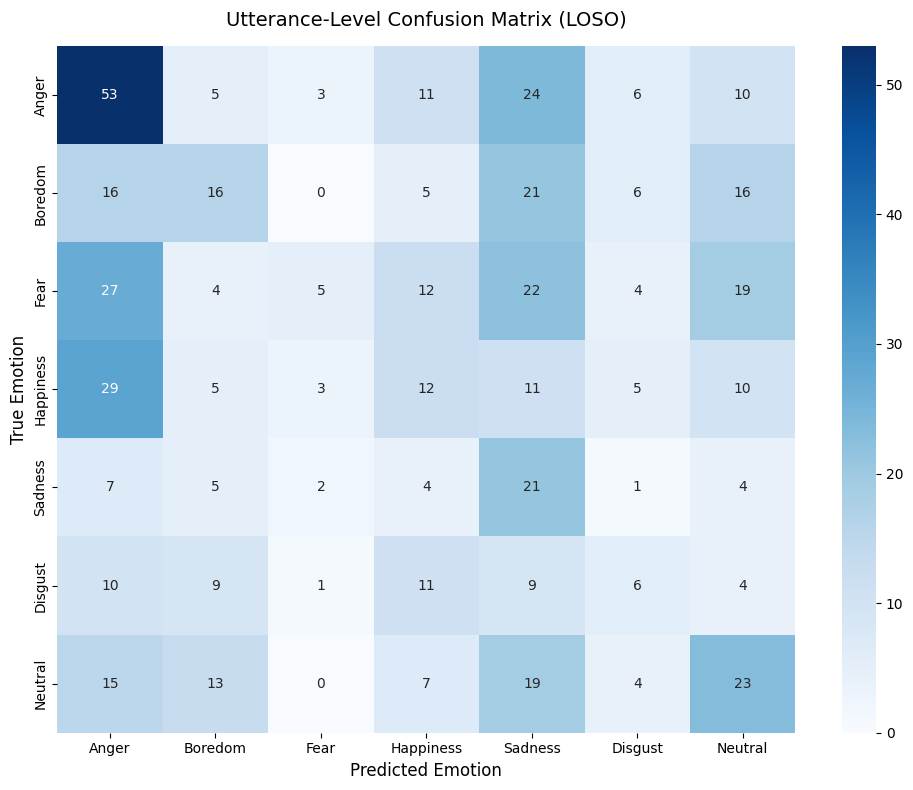

Saved confusion matrix figure to: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_comb_norm_loso/confusion_dcnn_processed_emodb_comb_norm_loso.png


In [9]:
# Utterance-level evaluation + confusion matrix (supports original and LOSO modes)
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

from utility import EMOTION_ENG_MAP

if SPLIT_MODE == "loso":
    if 'y_true_cv' not in globals() or 'y_pred_cv' not in globals():
        raise ValueError("Run Cell 10 first to train/evaluate all folds and create y_true_cv/y_pred_cv.")

    y_true_utt = y_true_cv
    y_pred_utt = y_pred_cv

else:
    # Original mode: get segment-level predictions on one test split and aggregate to utterance level
    model.eval()
    segment_preds = []
    segment_true = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            segment_preds.extend(preds.tolist())
            segment_true.extend(labels.numpy().tolist())

    segment_preds = np.array(segment_preds)
    segment_true = np.array(segment_true)

    u_ids_test = np.load(os.path.join(DATASET_PATH, "utterance_ids_test.npy"))
    if not (len(u_ids_test) == len(segment_preds) == len(segment_true)):
        raise ValueError(
            f"Length mismatch: utterance_ids={len(u_ids_test)}, preds={len(segment_preds)}, labels={len(segment_true)}"
        )

    utt_pred_buckets = defaultdict(list)
    utt_true_label = {}
    for uid, pred, true_label in zip(u_ids_test, segment_preds, segment_true):
        utt_pred_buckets[uid].append(pred)
        if uid not in utt_true_label:
            utt_true_label[uid] = true_label

    def majority_vote(labels):
        counts = defaultdict(int)
        for lb in labels:
            counts[int(lb)] += 1
        return max(counts, key=counts.get)

    y_true_utt = []
    y_pred_utt = []
    for uid, pred_list in utt_pred_buckets.items():
        y_true_utt.append(utt_true_label[uid])
        y_pred_utt.append(majority_vote(pred_list))

    y_true_utt = np.array(y_true_utt)
    y_pred_utt = np.array(y_pred_utt)

# Metrics + confusion matrix
utt_acc = accuracy_score(y_true_utt, y_pred_utt)
report_text = classification_report(y_true_utt, y_pred_utt)
print(f"Utterance-level accuracy ({SPLIT_MODE}): {utt_acc * 100:.2f}%")
print("\nUtterance-level classification report:")
print(report_text)

EMOTION_NAMES = [EMOTION_ENG_MAP[i] for i in range(len(EMOTION_ENG_MAP))]
cm = confusion_matrix(y_true_utt, y_pred_utt, labels=np.arange(len(EMOTION_NAMES)))

# Save printed outputs to results/training_report_dcnn_<dataset name>.txt
os.makedirs(RESULTS_DIR, exist_ok=True)
report_path = os.path.join(RESULTS_DIR, f"training_report_dcnn_{DATASET}.txt")
with open(report_path, "w") as f:
    f.write(f"Dataset: {DATASET}\n")
    f.write(f"Split mode: {SPLIT_MODE}\n")
    f.write(f"Utterance-level accuracy: {utt_acc * 100:.2f}%\n\n")
    f.write("Utterance-level classification report:\n")
    f.write(report_text)

    f.write("\n\nDCNN training and test logs:\n")
    if 'dcnn_training_logs' in globals() and len(dcnn_training_logs) > 0:
        for line in dcnn_training_logs:
            f.write(f"{line}\n")
    else:
        f.write("No captured logs found in memory. Run Cell 10 before this cell.\n")
print(f"Saved training report to: {report_path}")

# Save confusion matrix figure
cm_fig_path = os.path.join(RESULTS_DIR, f"confusion_dcnn_{DATASET}.png")
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=EMOTION_NAMES,
    yticklabels=EMOTION_NAMES
)
plt.title(f'Utterance-Level Confusion Matrix ({SPLIT_MODE.upper()})', fontsize=14, pad=15)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)
plt.tight_layout()
plt.savefig(cm_fig_path)
plt.show()
print(f"Saved confusion matrix figure to: {cm_fig_path}")

---

# 3. DTPM + SVM (Utterance-Level)

This section converts segment features into utterance-level features (DTPM), then trains SVM classifiers.

Mode behavior:
- original: one SVM trained on one split
- loso: one SVM trained per fold, then fold test predictions are collated into final metrics

Recommended run order for Section 3:
1. Run Cells 16 to 22 in order
2. For LOSO mode, make sure Section 2 has already produced fold DCNN checkpoints

In [ ]:
import torch
import torch.nn as nn
from collections import defaultdict
from torchvision import models, transforms
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [ ]:
# ==========================================
# 1. SETUP THE FEATURE EXTRACTOR (DCNN -> FC7)
# ==========================================
print("Preparing FC7 feature extraction utilities...")

# Make this section runnable even if Section 2 wasn't executed in this kernel.
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device was not defined. Using device: {device}")

def build_fc7_extractor(model_path):
    """Load a trained DCNN checkpoint and expose FC7 features."""
    feature_extractor = models.alexnet()
    num_ftrs = feature_extractor.classifier[6].in_features
    feature_extractor.classifier[6] = nn.Linear(num_ftrs, 7)
    feature_extractor.load_state_dict(torch.load(model_path, map_location=device))

    # Keep layers up to FC7, remove final classification layer
    feature_extractor.classifier = nn.Sequential(*list(feature_extractor.classifier.children())[:5])
    feature_extractor.eval()
    return feature_extractor.to(device)

def extract_fc7(segments_array, feature_extractor):
    """Extract FC7 features for all segments of one utterance."""
    processed_tensors = []

    for img in segments_array:
        img_copy = img.copy()

        # Min-Max scaling per channel
        for c in range(3):
            min_v, max_v = img_copy[c].min(), img_copy[c].max()
            if max_v > min_v:
                img_copy[c] = (img_copy[c] - min_v) / (max_v - min_v)
            else:
                img_copy[c] = 0.0

        img_transposed = img_copy.transpose(1, 2, 0)
        # ToTensor may keep float64 when source ndarray is float64; force float32 for AlexNet.
        tensor = transform(img_transposed).float().unsqueeze(0)
        processed_tensors.append(tensor)

    batch_tensor = torch.cat(processed_tensors).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        return feature_extractor(batch_tensor).cpu().numpy()

if SPLIT_MODE == "original":
    if not os.path.exists(DCNN_PATH):
        raise FileNotFoundError(f"DCNN checkpoint not found: {DCNN_PATH}")
    fc7_extractor = build_fc7_extractor(DCNN_PATH)
    print(f"Loaded FC7 extractor from: {DCNN_PATH}")
else:
    print("LOSO mode: FC7 extractor will be loaded per fold.")

In [ ]:
# ==========================================
# 2. DISCRIMINANT TEMPORAL PYRAMID MATCHING (DTPM)
# ==========================================
def lp_norm_pooling(matrix, p=1.12):
    # Lp pooling used by DTPM to summarize each temporal block.
    return np.power(np.mean(np.power(np.abs(matrix), p), axis=0), 1/p)

def dtpm(segment_features, L=2):
    """Convert chronological FC7 segment vectors into one utterance-level vector."""
    N = segment_features.shape[0]
    final_feature = []

    # Level 0: full sequence (1 block)
    final_feature.append(lp_norm_pooling(segment_features) * (1 / (2**L)))

    # Level 1: split into 2 temporal halves
    if N >= 2:
        mid = N // 2
        final_feature.append(lp_norm_pooling(segment_features[:mid]) * (1 / (2**L)))
        final_feature.append(lp_norm_pooling(segment_features[mid:]) * (1 / (2**L)))
    else:
        final_feature.extend([np.zeros(4096)] * 2)

    # Level 2: split into 4 temporal quarters
    if L == 2:
        if N >= 4:
            q_size = N // 4
            for i in range(4):
                start = i * q_size
                end = (i + 1) * q_size if i != 3 else N
                final_feature.append(lp_norm_pooling(segment_features[start:end]) * (1 / (2**(L-1))))
        else:
            final_feature.extend([np.zeros(4096)] * 4)

    return np.concatenate(final_feature)

In [ ]:
# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================
def process_dataset_to_global_features(dataset_dir, split_name, feature_extractor):
    """Build utterance-level DTPM features from segment-level arrays."""
    print(f"\nProcessing {split_name} set from: {dataset_dir}")
    X_segs = np.load(os.path.join(dataset_dir, f"X_{split_name}.npy"))
    y_lbls = np.load(os.path.join(dataset_dir, f"y_{split_name}.npy"))
    u_ids = np.load(os.path.join(dataset_dir, f"utterance_ids_{split_name}.npy"))

    # Group all segments belonging to the same utterance id.
    utterance_dict = {}
    for i, uid in enumerate(u_ids):
        if uid not in utterance_dict:
            utterance_dict[uid] = {'segments': [], 'label': y_lbls[i]}
        utterance_dict[uid]['segments'].append(X_segs[i])

    X_global, y_global = [], []
    for uid, data in utterance_dict.items():
        # 1) FC7 per segment, 2) DTPM temporal pooling, 3) store utterance label.
        fc7_feats = extract_fc7(np.array(data['segments']), feature_extractor)
        global_feat = dtpm(fc7_feats, L=2)
        X_global.append(global_feat)
        y_global.append(data['label'])

    return np.array(X_global), np.array(y_global)

print("Feature pipeline ready.")
if SPLIT_MODE == "original":
    print("Original mode: global features will be computed in the next cell.")
else:
    print("LOSO mode: global features will be computed fold-by-fold in the next cell.")

In [ ]:
# ==========================================
# 4. SVM CLASSIFICATION (ORIGINAL + LOSO)
# ==========================================
svm_logs = []
def log_svm(message):
    print(message)
    svm_logs.append(str(message))

# These lists hold final utterance-level labels/predictions.
svm_all_true = []
svm_all_pred = []

if SPLIT_MODE == "original":
    log_svm("Running SVM in ORIGINAL mode...")

    # Build global utterance-level features from train and test splits
    X_train_global, y_train_global = process_dataset_to_global_features(DATASET_PATH, "train", fc7_extractor)
    X_test_global, y_test_global = process_dataset_to_global_features(DATASET_PATH, "test", fc7_extractor)

    # Standardize features before linear SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_global)
    X_test_scaled = scaler.transform(X_test_global)

    svm_classifier = SVC(kernel='linear', decision_function_shape='ovo')
    svm_classifier.fit(X_train_scaled, y_train_global)
    predictions = svm_classifier.predict(X_test_scaled)

    svm_all_true = y_test_global.tolist()
    svm_all_pred = predictions.tolist()

    # Save artifacts for original mode
    joblib.dump(svm_classifier, SVM_PATH)
    joblib.dump(scaler, os.path.join(MODEL_DIR, f"scaler_{DATASET}.joblib"))
    log_svm(f"Saved SVM model to: {SVM_PATH}")

else:
    log_svm("Running SVM in LOSO mode (train/evaluate per fold)...")

    for fold_name in FOLD_NAMES:
        fold_path       = os.path.join(DATASET_PATH, fold_name)
        fold_dcnn_path  = os.path.join(MODEL_DIR, f"dcnn_{DATASET}_{fold_name}.pth")

        if not os.path.exists(fold_dcnn_path):
            raise FileNotFoundError(
                f"DCNN checkpoint for {fold_name} not found: {fold_dcnn_path}. "
                "Run DCNN LOSO training section first."
            )

        log_svm("-" * 70)
        log_svm(f"Fold: {fold_name}")

        # Load fold-specific DCNN and extract fold-specific global features
        fold_extractor = build_fc7_extractor(fold_dcnn_path)
        X_train_global, y_train_global = process_dataset_to_global_features(fold_path, "train", fold_extractor)
        X_test_global, y_test_global = process_dataset_to_global_features(fold_path, "test", fold_extractor)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_global)
        X_test_scaled = scaler.transform(X_test_global)

        fold_svm = SVC(kernel='linear', decision_function_shape='ovo')
        fold_svm.fit(X_train_scaled, y_train_global)
        fold_predictions = fold_svm.predict(X_test_scaled)

        fold_acc = accuracy_score(y_test_global, fold_predictions)
        log_svm(f"Fold utterance-level SVM accuracy: {fold_acc * 100:.2f}%")

        svm_all_true.extend(y_test_global.tolist())
        svm_all_pred.extend(fold_predictions.tolist())

        # Save each fold model/scaler separately
        fold_svm_path    = os.path.join(MODEL_DIR, f"svm_{DATASET}_{fold_name}.joblib")
        fold_scaler_path = os.path.join(MODEL_DIR, f"scaler_{DATASET}_{fold_name}.joblib")
        joblib.dump(fold_svm, fold_svm_path)
        joblib.dump(scaler, fold_scaler_path)
        log_svm(f"Saved fold SVM to: {fold_svm_path}")

# Final collated SVM results (single split for original, all folds for LOSO)
svm_y_true_final    = np.array(svm_all_true)
svm_y_pred_final    = np.array(svm_all_pred)
svm_acc_final       = accuracy_score(svm_y_true_final, svm_y_pred_final)
svm_report_final    = classification_report(svm_y_true_final, svm_y_pred_final)

log_svm("=" * 70)
log_svm(f"Final SVM utterance-level accuracy ({SPLIT_MODE}): {svm_acc_final * 100:.2f}%")
log_svm("Final SVM classification report:")
print(svm_report_final)
svm_logs.append(svm_report_final)

svm_report_path = os.path.join(RESULTS_DIR, f"classification_report_{DATASET}.txt")
with open(svm_report_path, "w") as f:
    for line in svm_logs:
        f.write(f"{line}\n")
log_svm(f"Saved classification log to: {svm_report_path}")

In [ ]:
# Keep backward-compatible variable names for downstream plotting/report cells
predictions = svm_y_pred_final
y_test_global = svm_y_true_final
accuracy = svm_acc_final
report = svm_report_final

print("SVM final results are ready for plotting and saved reporting.")
print(f"Accuracy (WAR): {accuracy * 100:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from utility import EMOTION_ENG_MAP

EMOTION_NAMES = [EMOTION_ENG_MAP[i] for i in range(len(EMOTION_ENG_MAP))]
cm = confusion_matrix(y_test_global, predictions, labels=np.arange(len(EMOTION_NAMES)))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=EMOTION_NAMES,
    yticklabels=EMOTION_NAMES
)
plt.title(f'SVM Confusion Matrix ({SPLIT_MODE.upper()})', fontsize=14, pad=15)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)
plt.tight_layout()

svm_cm_path = os.path.join(RESULTS_DIR, f"confusion_svm_{DATASET}.png")
plt.savefig(svm_cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved SVM confusion matrix to: {svm_cm_path}")